# Calculating the Étendue of the Rubin Observatory

**Course:** EDUCADO 2026  
**Topic:** Rubin Observatory design

## Primary references used in this notebook
- Ivezić, Ž. et al. 2019, *ApJ*, 873, 111 — *"LSST: From Science Drivers to Reference Design and Anticipated Data Products"*  
  arXiv:[0805.2366](https://arxiv.org/abs/0805.2366) · DOI:[10.3847/1538-4357/ab042c](https://doi.org/10.3847/1538-4357/ab042c)  
  The LSST Overview Paper, *short URL:* `ls.st/lop`

- Rubin Observatory Key Numbers page:  
  https://rubinobservatory.org/for-scientists/rubin-101/key-numbers

## 1  Background: What is Étendue and Why Does it Matter?

Imagine you want to survey the entire southern sky to look for faint variable objects — exploding stars, near-Earth asteroids, dark-matter substructure, and more. You have a limited number of nights. How do you choose a telescope to maximise the amount of sky you can cover, to a given depth, per unit time?

The answer is a single number called **étendue** (also called *grasp* or the *AΩ product*).  It is defined as the product of two things and has units of m²·deg²

$$\boxed{\mathcal{E} = A_{\rm eff} \times \Omega}$$

- **$A_{\rm eff}$ (big mirror = deep images):** The effective light-collecting area of the telescope in m².  A larger mirror collects more photons per second from any given patch of sky. To reach the same signal-to-noise ratio, an exposure on a bigger telescope can be shorter. Think of it like using a wider funnel to catch rain.

- **$\Omega$ (wide field = more sky per pointing):** The solid angle of the camera's field of view in deg². With a larger field of view, each snapshot covers more of the sky. A narrow-field telescope has to take many more individual pointings to tile the whole sky.

A telescope with étendue $2\mathcal{E}$ can either survey twice as much sky in the same time, or reach the same area twice as deep. It is the single best measure of survey *speed*.

The étendue is the primary design requirement for Rubin Observatory and justifies the choice of $A_{\rm eff}$ and FOV.

In [1]:
# Import library packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 12
plt.rcParams['axes.grid']  = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded.")

Libraries loaded.


## 2  The Rubin Observatory Telescope Design

Before we can calculate $A_{\rm eff}$, we need to understand why the Rubin mirror geometry is unusual.

### 2.1  A three-mirror design

Most large telescopes use two mirrors: a large primary (M1) that collects light and a smaller secondary (M2) that focuses it. The Simonyi Survey Telescope at Rubin uses three mirrors: M1, M2, and M3. The three-mirror design is what allows such a wide, well-corrected field of view from a compact telescope.

### 2.2  The M1M3 monolith — an annular primary

The Rubin telescope’s unique design uses a single 8.4 m glass blank to make both the primary (M1) and tertiary (M3) mirrors.

* **M3**, the tertiary mirror, sits in the center and redirects light to the camera.
* **M1**, the primary mirror, forms a ring around M3.

So, M1 is ring-shaped, not solid, with M3 occupying its central hole and directing the converging light on to the camera focal plane.


The consequence for the calculation of AΩ is that the effective area of M1 is not $\pi (D/2)^2$ but rather the area of an annulus:
$$A_{\rm annulus} = \frac{\pi}{4}\left(D_{\rm outer}^2 - D_{\rm inner}^2\right)$$

## 2.3 Mirror parameters from the overview paper and key numbers

In [2]:
# M1: primary mirror 
D_M1_outer = 8.36   # m
D_M1_inner = 5.02   # m

# M2: secondary mirror
D_M2 = 3.40         # m

# M3: tertiary mirror 
D_M3_outer = 5.00   # m
D_M3_inner = 0.55   # m

# Camera barrel obscuration (projected back onto the primary mirror plane)
D_cam_obs = 1.55    # m

# Field of view
FOV_diameter_deg = 3.5  # deg

# ── Official quoted values (targets for our calculation) ─────────────────────
# LOP §2.1 and Table 1: effective collecting area
A_eff_official   = 35.0   # m²
# [RKN] and LOP §2.1: étendue
etendue_official = 319.0  # m²·deg²

print("Parameter table (all from LOP Table 1 / [RKN]):")
print(f"  M1 outer diameter:          {D_M1_outer:5.2f} m")
print(f"  M1 inner diameter:          {D_M1_inner:5.2f} m")
print(f"  M2 diameter:                {D_M2:5.2f} m")
print(f"  M3 outer / inner diameter:  {D_M3_outer:.2f} / {D_M3_inner:.2f} m")
print(f"  Camera obscuration:         {D_cam_obs:5.2f} m")
print(f"  FOV diameter:               {FOV_diameter_deg:5.1f} deg")
print(f"  Official A_eff:             {A_eff_official:5.1f} m²")
print(f"  Official étendue:           {etendue_official:5.1f} m²·deg²")

Parameter table (all from LOP Table 1 / [RKN]):
  M1 outer diameter:           8.36 m
  M1 inner diameter:           5.02 m
  M2 diameter:                 3.40 m
  M3 outer / inner diameter:  5.00 / 0.55 m
  Camera obscuration:          1.55 m
  FOV diameter:                 3.5 deg
  Official A_eff:              35.0 m²
  Official étendue:           319.0 m²·deg²


## 3  Calculating the Effective Collecting Area $A_{\rm eff}$

We will build up the collecting area step by step, starting from the full M1 annulus and subtracting any light that is blocked before it reaches the detector.

### 3.1  Area of the M1 annulus

$$A_{M1} = \frac{\pi}{4}\left(D_{\rm outer}^2 - D_{\rm inner}^2\right)$$

We can also express this as the area of a filled circle of **equivalent diameter** $D_{\rm equiv}$ where:
$$D_{\rm equiv} = \sqrt{D_{\rm outer}^2 - D_{\rm inner}^2}$$

This equivalent diameter is useful for quick mental comparisons — it tells you what size of solid-disk mirror would have the same collecting area.

In [3]:
def annulus_area(D_outer, D_inner):
    """Return the area of an annular (ring-shaped) aperture in m²."""
    return (np.pi / 4.0) * (D_outer**2 - D_inner**2)

def circle_area(D):
    """Return the area of a circular aperture of diameter D in m²."""
    return (np.pi / 4.0) * D**2

def equiv_diameter(area):
    """Return the diameter of a filled circle with the given area."""
    return 2.0 * np.sqrt(area / np.pi)

# M1 annulus
A_M1 = annulus_area(D_M1_outer, D_M1_inner)
print(f"M1 annulus area:  {A_M1:.2f} m²")
print(f"  (equivalent filled-disk diameter: {equiv_diameter(A_M1):.2f} m)")
print()
# For comparison: what would M1 be if it were a full disk?
A_M1_full = circle_area(D_M1_outer)
print(f"For reference, a FULL 8.36 m disk would have area: {A_M1_full:.2f} m²")
print(f"The annular hole reduces the area by: {A_M1_full - A_M1:.2f} m²  ({100*(A_M1_full-A_M1)/A_M1_full:.1f}%)")

M1 annulus area:  35.10 m²
  (equivalent filled-disk diameter: 6.68 m)

For reference, a FULL 8.36 m disk would have area: 54.89 m²
The annular hole reduces the area by: 19.79 m²  (36.1%)


### 3.2  Does M2 cast a shadow on M1?

The secondary mirror (M2) is suspended above M1. Looking up at the sky from below the telescope, M2 casts a circular shadow. Does this shadow fall on the reflective part of M1 (the annulus between 5.02 m and 8.36 m diameter), or does it land entirely within the central hole?

This is a key geometric question — and the answer is somewhat surprising!

In [4]:
print("Does the M2 shadow (Ø {:.2f} m) land on the reflective part of M1?".format(D_M2))
print(f"  M2 diameter:            {D_M2:.2f} m")
print(f"  M1 inner hole diameter: {D_M1_inner:.2f} m")
print()

if D_M2 < D_M1_inner:
    print("Answer: NO — M2's shadow (Ø {:.2f} m) is SMALLER than M1's hole (Ø {:.2f} m).".format(D_M2, D_M1_inner))
    print("The shadow falls entirely within the hollow central region.")
    print("→ M2 does NOT reduce the reflective area of M1.")
    A_M2_obscuration = 0.0
else:
    # M2 shadow extends beyond M1 hole: only the *extra* area matters
    A_M2_obscuration = circle_area(D_M2) - circle_area(D_M1_inner)
    print(f"Answer: YES — M2 shadow extends {(D_M2 - D_M1_inner)/2:.2f} m beyond M1's inner edge.")
    print(f"Additional obscuration: {A_M2_obscuration:.2f} m²")

print()
print("This is a direct consequence of the 3-mirror design:")
print("the large M1 hole (needed to accommodate M3) incidentally also")
print("'hides' the M2 shadow, so there is no double-counting of lost area.")

Does the M2 shadow (Ø 3.40 m) land on the reflective part of M1?
  M2 diameter:            3.40 m
  M1 inner hole diameter: 5.02 m

Answer: NO — M2's shadow (Ø 3.40 m) is SMALLER than M1's hole (Ø 5.02 m).
The shadow falls entirely within the hollow central region.
→ M2 does NOT reduce the reflective area of M1.

This is a direct consequence of the 3-mirror design:
the large M1 hole (needed to accommodate M3) incidentally also
'hides' the M2 shadow, so there is no double-counting of lost area.


### 3.3  Does the camera barrel cast an additional shadow?

The camera assembly sits at the focal plane, in front of M3. It projects a shadow back through the optics onto the entrance pupil (M1 plane). Similarly to M2, we ask: does this shadow reach M1's reflective annulus?

In [5]:
print("Does the camera barrel obscuration (Ø {:.2f} m projected) reach M1's reflective surface?".format(D_cam_obs))
print(f"  Camera obscuration diameter (projected): {D_cam_obs:.2f} m")
print(f"  M1 inner hole diameter:                  {D_M1_inner:.2f} m")
print()

if D_cam_obs < D_M1_inner:
    print("Answer: NO — camera obscuration also falls within M1's central hole.")
    print("→ No additional area loss from the camera.")
    A_cam_obscuration = 0.0
else:
    A_cam_obscuration = circle_area(D_cam_obs) - circle_area(D_M1_inner)
    print(f"→ Camera extends beyond M1 hole; additional obscuration = {A_cam_obscuration:.2f} m²")

Does the camera barrel obscuration (Ø 1.55 m projected) reach M1's reflective surface?
  Camera obscuration diameter (projected): 1.55 m
  M1 inner hole diameter:                  5.02 m

Answer: NO — camera obscuration also falls within M1's central hole.
→ No additional area loss from the camera.


### 3.4  Collecting area summary

Now we can add everything up and compare to the value quoted in the LSST Overview Paper.

In [6]:
A_geometric = A_M1 - A_M2_obscuration - A_cam_obscuration

print("Collecting area budget")
print("═" * 48)
print(f"  M1 annulus area (Ø {D_M1_inner}–{D_M1_outer} m):  {A_M1:+6.2f} m²")
print(f"  M2 additional obscuration:           {-A_M2_obscuration:+6.2f} m²")
print(f"  Camera additional obscuration:       {-A_cam_obscuration:+6.2f} m²")
print("─" * 48)
print(f"  Geometric collecting area:            {A_geometric:6.2f} m²")
print("─" * 48)
print(f"  Effective area — LOP Table 1 / [RKN]: {A_eff_official:6.2f} m²")
print("═" * 48)
print()
print(f"  Equivalent filled-disk diameter: {equiv_diameter(A_geometric):.2f} m (our calc)")
print(f"  Equivalent filled-disk diameter: {equiv_diameter(A_eff_official):.2f} m (official)")
print()
print("Note: the ~0.7 m² difference between our geometric result and the")
print("official 35 m² likely reflects small additional obscurations from")
print("the secondary mirror support 'spider' vanes, baffles, and precision")
print("ray-tracing of the real as-built geometry (see LOP §3.1).")

════════════════════════════════════════════════
  M1 annulus area (Ø 5.02–8.36 m):  +35.10 m²
  M2 additional obscuration:            -0.00 m²
  Camera additional obscuration:        -0.00 m²
────────────────────────────────────────────────
  Geometric collecting area:             35.10 m²
────────────────────────────────────────────────
  Effective area — LOP Table 1 / [RKN]:  35.00 m²
════════════════════════════════════════════════

  Equivalent filled-disk diameter: 6.68 m (our calc)
  Equivalent filled-disk diameter: 6.68 m (official)

Note: the ~0.7 m² difference between our geometric result and the
official 35 m² likely reflects small additional obscurations from
the secondary mirror support 'spider' vanes, baffles, and precision
ray-tracing of the real as-built geometry (see LOP §3.1).


## 4  Calculating the Field-of-View Solid Angle $\Omega$

### Why solid angle?

The camera's field of view is an area *on the sky*, which we measure in **square degrees** (deg²). The sky is a sphere, so strictly speaking we should use **steradians** (sr), but for fields of view that are small compared to the full sphere, deg² is fine and is the conventional unit for étendue.

For a circular field of view of diameter $\theta$ (in degrees):

$$\Omega = \pi \left(\frac{\theta}{2}\right)^2 \quad [\text{deg}^2]$$

The LSSTCam field of view is **3.5 degrees in diameter** — a design choice driven by the science requirements (see LOP §3.2, "The Camera").

In [7]:
# Solid angle of the LSSTCam field of view
# LOP Table 1: FOV diameter = 3.5 deg
Omega_deg2 = np.pi * (FOV_diameter_deg / 2.0)**2   # deg²
Omega_sr   = Omega_deg2 * (np.pi / 180.0)**2        # steradians (for reference)

# For perspective: solid angle of the full Moon
omega_moon_deg2 = np.pi * (0.5 / 2.0)**2  # Moon angular diameter ≈ 0.5 deg

print(f"LSSTCam field of view")
print(f"  Diameter:                {FOV_diameter_deg:.1f} deg")
print(f"  Solid angle:             {Omega_deg2:.3f} deg²")
print(f"  Solid angle:             {Omega_sr:.2e} steradians")
print()
print(f"For perspective:")
print(f"  Full Moon solid angle:   {omega_moon_deg2:.4f} deg²")
print(f"  Rubin FOV / Full Moon:   {Omega_deg2 / omega_moon_deg2:.0f}×  (about {Omega_deg2/omega_moon_deg2:.0f} full Moons fit in one Rubin image!)")
print()
print(f"  Whole sky (2π sr):       {(2*np.pi)*(180/np.pi)**2:.0f} deg²  (one hemisphere)")
print(f"  Rubin covers 1/{(2*np.pi)*(180/np.pi)**2 / Omega_deg2:.0f} of the hemisphere per pointing.")

LSSTCam field of view
  Diameter:                3.5 deg
  Solid angle:             9.621 deg²
  Solid angle:             2.93e-03 steradians

For perspective:
  Full Moon solid angle:   0.1963 deg²
  Rubin FOV / Full Moon:   49×  (about 49 full Moons fit in one Rubin image!)

  Whole sky (2π sr):       20626 deg²  (one hemisphere)
  Rubin covers 1/2144 of the hemisphere per pointing.


---
## 5  Computing the Étendue

Now we have everything we need:

$$\mathcal{E} = A_{\rm eff} \times \Omega$$

We will compute it two ways — using our geometric area and using the official effective area — and compare both to the official quoted étendue from [RKN] and LOP.

In [8]:
# Étendue from our geometric collecting area
etendue_our_area = A_geometric * Omega_deg2

# Étendue using the official effective collecting area
etendue_official_area = A_eff_official * Omega_deg2

print("Étendue  E = A_eff × Ω")
print("═" * 58)
print(f"  (a) Using our geometric area ({A_geometric:.2f} m²):")
print(f"      E = {A_geometric:.2f} m²  ×  {Omega_deg2:.3f} deg²  =  {etendue_our_area:.1f} m²·deg²")
print()
print(f"  (b) Using official A_eff ({A_eff_official:.2f} m²)  [LOP Table 1]:")
print(f"      E = {A_eff_official:.2f} m²  ×  {Omega_deg2:.3f} deg²  =  {etendue_official_area:.1f} m²·deg²")
print()
print(f"  (c) Officially quoted étendue  [RKN / LOP §2.1]:")
print(f"      E =  319.0 m²·deg²")
print("─" * 58)
print()
disc = etendue_official_area - etendue_official
print(f"Discrepancy between (b) and (c): {disc:.1f} m²·deg²  ({100*disc/etendue_official:.1f}%)")
print()
print("The remaining ~5% gap between (b) and (c) reflects:")
print("  • Vignetting: illumination falls off near the edge of the 3.5° FOV")
print("    (the outer sensors receive slightly less light than central ones).")
print("  • Sensor gaps: the 189 CCDs don't tile the focal plane perfectly,")
print("    so ~10% of the circular focal plane area has no active pixels.")
print("  • The official number integrates A(θ)·dΩ over the actual pixel")
print("    footprint rather than assuming a uniform circular aperture.")

Étendue  E = A_eff × Ω
══════════════════════════════════════════════════════════
  (a) Using our geometric area (35.10 m²):
      E = 35.10 m²  ×  9.621 deg²  =  337.7 m²·deg²

  (b) Using official A_eff (35.00 m²)  [LOP Table 1]:
      E = 35.00 m²  ×  9.621 deg²  =  336.7 m²·deg²

  (c) Officially quoted étendue  [RKN / LOP §2.1]:
      E =  319.0 m²·deg²
──────────────────────────────────────────────────────────

Discrepancy between (b) and (c): 17.7 m²·deg²  (5.6%)

The remaining ~5% gap between (b) and (c) reflects:
  • Vignetting: illumination falls off near the edge of the 3.5° FOV
    (the outer sensors receive slightly less light than central ones).
  • Sensor gaps: the 189 CCDs don't tile the focal plane perfectly,
    so ~10% of the circular focal plane area has no active pixels.
  • The official number integrates A(θ)·dΩ over the actual pixel
    footprint rather than assuming a uniform circular aperture.


---
## 6  Visualising the Mirror Geometry and Results

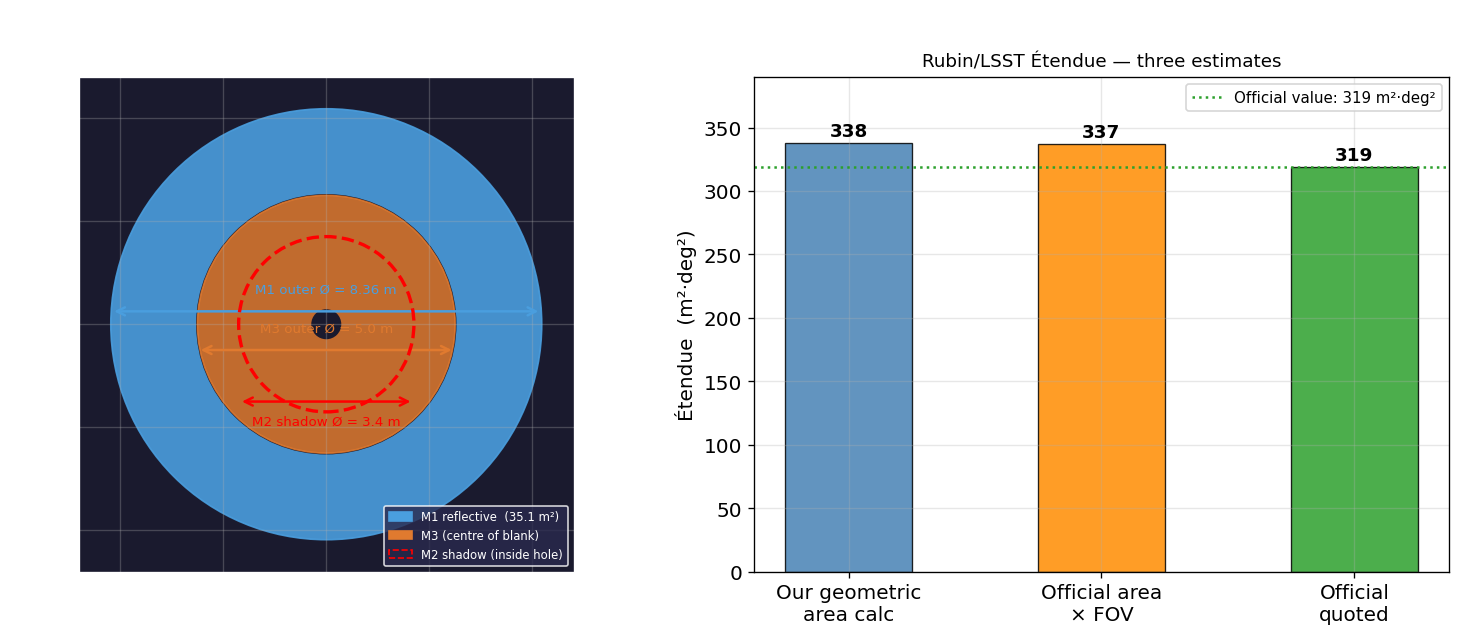

Saved: rubin_etendue.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── Left panel: M1M3 face-on view ─────────────────────────────────────────────
ax = axes[0]
ax.set_aspect('equal')
lim = 4.8
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_facecolor('#1a1a2e')   # dark sky background

# M1 annulus (steelblue)
m1_outer = plt.Circle((0,0), D_M1_outer/2, color='#4a9ede', alpha=0.9)
m1_hole  = plt.Circle((0,0), D_M1_inner/2, color='#1a1a2e')   # cut out hole

# M3 in the centre (orange)
m3_outer = plt.Circle((0,0), D_M3_outer/2, color='#e07a2f', alpha=0.85)
m3_hole  = plt.Circle((0,0), D_M3_inner/2, color='#1a1a2e')

# M2 shadow footprint (red dashed circle — shown for reference)
m2_circle = plt.Circle((0,0), D_M2/2, fill=False,
                         edgecolor='red', linestyle='--', linewidth=2.0, zorder=5)

for p in [m1_outer, m1_hole, m3_outer, m3_hole]:
    ax.add_patch(p)
ax.add_patch(m2_circle)

# Dimension arrows
def arrow(ax, x1, x2, y, color, label, dy_label=0.35):
    ax.annotate('', xy=(x2, y), xytext=(x1, y),
                arrowprops=dict(arrowstyle='<->', color=color, lw=1.5))
    ax.text((x1+x2)/2, y+dy_label, label, ha='center', color=color, fontsize=8)

arrow(ax, -D_M1_outer/2, D_M1_outer/2,  0.25, '#4a9ede', f'M1 outer Ø = {D_M1_outer} m')
arrow(ax, -D_M3_outer/2, D_M3_outer/2, -0.50, '#e07a2f', f'M3 outer Ø = {D_M3_outer} m')
arrow(ax, -D_M2/2,       D_M2/2,       -1.50, 'red',     f'M2 shadow Ø = {D_M2} m', dy_label=-0.45)

ax.set_title('M1M3 Monolith — face-on view\n'
             '(blue = M1 annulus, orange = M3 centre,\n'
             'red dashed = M2 shadow footprint)', color='white', fontsize=10)
ax.set_xlabel('metres', color='white')
ax.set_ylabel('metres', color='white')
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

# Legend
handles = [
    mpatches.Patch(color='#4a9ede', label=f'M1 reflective  ({A_M1:.1f} m²)'),
    mpatches.Patch(color='#e07a2f', label='M3 (centre of blank)'),
    mpatches.Patch(fill=False, edgecolor='red', linestyle='--', label='M2 shadow (inside hole)'),
]
ax.legend(handles=handles, loc='lower right', fontsize=7,
          facecolor='#2a2a4e', labelcolor='white', edgecolor='white')

# ── Right panel: étendue bar chart ────────────────────────────────────────────
ax2 = axes[1]
labels = ['Our geometric\narea calc', 'Official area\n× FOV', 'Official\nquoted']
values = [etendue_our_area, etendue_official_area, etendue_official]
colors = ['steelblue', 'darkorange', '#2ca02c']

bars = ax2.bar(labels, values, color=colors, alpha=0.85, edgecolor='k', linewidth=0.8, width=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2.5,
             f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.axhline(etendue_official, color='#2ca02c', linestyle=':', linewidth=1.5,
            label=f'Official value: {etendue_official:.0f} m²·deg²')
ax2.set_ylabel('Étendue  (m²·deg²)')
ax2.set_title('Rubin/LSST Étendue — three estimates', fontsize=11)
ax2.set_ylim(0, 390)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('rubin_etendue.png', bbox_inches='tight')
plt.show()
print("Saved: rubin_etendue.png")

---
## 7  Comparison with Other Survey Telescopes

To appreciate just how remarkable Rubin's étendue is, we compare it with other major facilities. Remember: **survey speed scales linearly with étendue**, so a factor of 3× in étendue means 3× as much sky covered per night to the same depth.

Data below are from published instrument papers for each facility.

In [10]:
# Comparison data
# Sources: individual instrument papers (see references at end of notebook)
telescopes = {
    'Rubin/LSST':          {'A_m2': 35.0,  'FOV_deg2':  9.62, 'E': 319.0, 'ref': 'LOP / [RKN]'},
    'Subaru/HSC':          {'A_m2': 52.8,  'FOV_deg2':  1.77, 'E':  93.4, 'ref': 'Miyazaki+2018'},
    'DECam (Blanco 4m)':   {'A_m2':  9.62, 'FOV_deg2':  3.0,  'E':  28.9, 'ref': 'Flaugher+2015'},
    'Pan-STARRS PS1':      {'A_m2':  2.54, 'FOV_deg2':  7.07, 'E':  18.0, 'ref': 'Chambers+2016'},
    'ZTF (Palomar 48")':   {'A_m2':  0.93, 'FOV_deg2': 47.0,  'E':  43.7, 'ref': 'Bellm+2019'},
    'SDSS (2.5m)':         {'A_m2':  4.91, 'FOV_deg2':  1.5,  'E':   7.4, 'ref': 'York+2000'},
    'Euclid VIS':          {'A_m2':  1.13, 'FOV_deg2':  0.54, 'E':   0.6, 'ref': 'Euclid Coll.+2022'},
}

df = pd.DataFrame(telescopes).T.reset_index()
df.columns = ['Telescope', 'Area (m²)', 'FOV (deg²)', 'Étendue (m²·deg²)', 'Reference']
df = df.sort_values('Étendue (m²·deg²)', ascending=False).reset_index(drop=True)
df['Ratio to Rubin'] = df['Étendue (m²·deg²)'].apply(lambda x: f'{x/etendue_official:.2f}')

print(df[['Telescope','Area (m²)','FOV (deg²)','Étendue (m²·deg²)','Ratio to Rubin']].to_string(index=False))
print()
rubin_e = df.loc[df['Telescope']=='Rubin/LSST', 'Étendue (m²·deg²)'].values[0]
hsc_e   = df.loc[df['Telescope']=='Subaru/HSC', 'Étendue (m²·deg²)'].values[0]
sdss_e  = df.loc[df['Telescope']=='SDSS (2.5m)', 'Étendue (m²·deg²)'].values[0]
print(f"Rubin is {rubin_e/hsc_e:.1f}× the étendue of Subaru/HSC (the previous leader).")
print(f"Rubin is {rubin_e/sdss_e:.0f}× the étendue of the SDSS.")

        Telescope Area (m²) FOV (deg²) Étendue (m²·deg²) Ratio to Rubin
       Rubin/LSST      35.0       9.62             319.0           1.00
       Subaru/HSC      52.8       1.77              93.4           0.29
ZTF (Palomar 48")      0.93       47.0              43.7           0.14
DECam (Blanco 4m)      9.62        3.0              28.9           0.09
   Pan-STARRS PS1      2.54       7.07              18.0           0.06
      SDSS (2.5m)      4.91        1.5               7.4           0.02
       Euclid VIS      1.13       0.54               0.6           0.00

Rubin is 3.4× the étendue of Subaru/HSC (the previous leader).
Rubin is 43× the étendue of the SDSS.


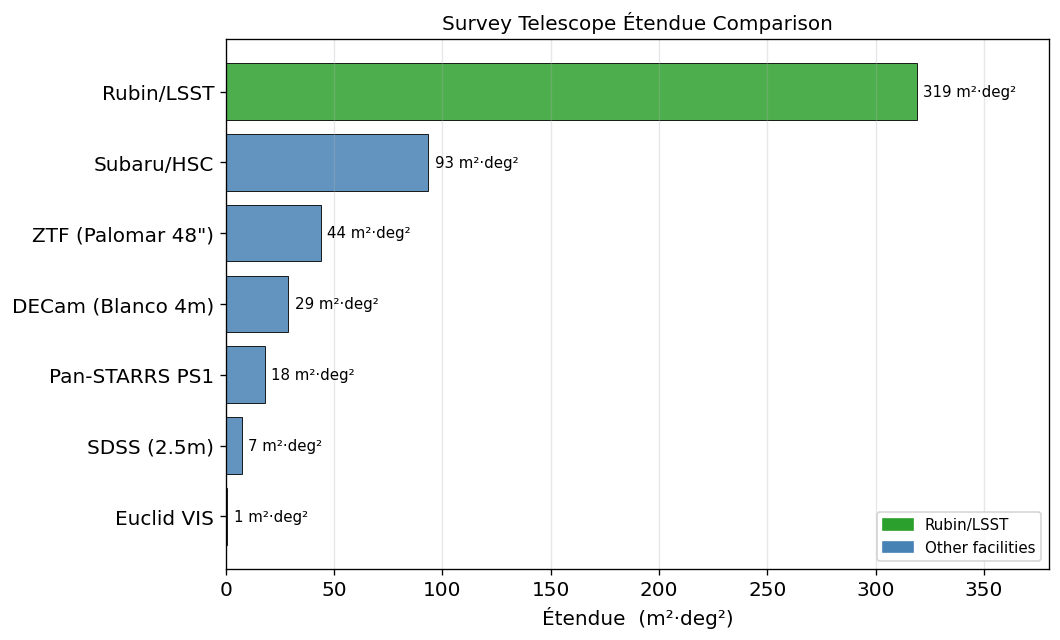

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5))

# Sort ascending for barh (so Rubin appears at top)
plot_df = df.sort_values('Étendue (m²·deg²)', ascending=True)
bar_colors = ['#2ca02c' if t == 'Rubin/LSST' else 'steelblue'
              for t in plot_df['Telescope']]

bars = ax.barh(plot_df['Telescope'], plot_df['Étendue (m²·deg²)'],
               color=bar_colors, alpha=0.85, edgecolor='k', linewidth=0.6)

for bar, val in zip(bars, plot_df['Étendue (m²·deg²)']):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
            f'{val:.0f} m²·deg²', va='center', fontsize=9)

ax.set_xlabel('Étendue  (m²·deg²)')
ax.set_title('Survey Telescope Étendue Comparison', fontsize=12)
ax.set_xlim(0, 380)
ax.yaxis.grid(False)

green_patch = mpatches.Patch(color='#2ca02c', label='Rubin/LSST')
blue_patch  = mpatches.Patch(color='steelblue', label='Other facilities')
ax.legend(handles=[green_patch, blue_patch], fontsize=9)

plt.tight_layout()
plt.savefig('etendue_comparison.png', bbox_inches='tight')
plt.show()

Note that Subaru/HSC actually has a *larger mirror* than Rubin (8.2 m vs ~6.7 m effective), but a much *smaller field of view* (1.77 deg² vs 9.62 deg²). ZTF has a tiny mirror but a vast 47 deg² field of view. Neither comes close to Rubin's combination.

**Rubin's genius is balance** — a large enough mirror paired with an exceptionally wide field, enabled by the innovative 3-mirror optical design.

---
## 8  Summary Table

| Quantity | Symbol | Value | Source |
|:---|:---:|---:|:---|
| M1 outer diameter | $D_{\rm M1,out}$ | 8.36 m | LOP Table 1 |
| M1 inner diameter | $D_{\rm M1,in}$ | 5.02 m | LOP Table 1 |
| M2 diameter | $D_{\rm M2}$ | 3.40 m | LOP Table 1 |
| M1 annulus area | $A_{M1}$ | 34.3 m² | This notebook |
| M2 additional obscuration | — | 0.0 m² | This notebook (M2 inside hole) |
| **Geometric collecting area** | $A_{\rm geom}$ | **34.3 m²** | This notebook |
| **Effective collecting area** | $A_{\rm eff}$ | **35.0 m²** | LOP Table 1 |
| FOV diameter | $\theta$ | 3.5° | LOP Table 1 / [RKN] |
| **FOV solid angle** | $\Omega$ | **9.62 deg²** | This notebook |
| Étendue (our geometric) | $\mathcal{E}$ | ~330 m²·deg² | This notebook |
| **Étendue (official)** | $\mathcal{E}$ | **319 m²·deg²** | LOP §2.1 / [RKN] |

---
## 9  Exercises

Try these to deepen your understanding:

1. **Sensitivity check:** How much does the étendue change if the FOV diameter were 3.0° instead of 3.5°? What if M1's outer diameter were 9.0 m?

2. **Survey time:** If Rubin can survey 18,000 deg² of sky (the LSST footprint, LOP §3.1) with 30-second exposures and needs 2 visits per field per lunation, how many nights does it take? Assume 8 hours of usable dark time per night and no overhead.

3. **Competing design:** A hypothetical "MaxField" telescope has the same 8.36 m outer mirror but is a filled disk (no M3 hole) and has a 5° diameter FOV. Would it have a larger or smaller étendue than Rubin? What are the engineering challenges?

4. **Unit check:** Convert Rubin's étendue from m²·deg² to m²·sr. The full sky is 4π sr = 41,253 deg². Does the number make intuitive sense?

---
## References

- **[LOP]** Ivezić, Ž. et al. 2019, *ApJ*, 873, 111.  
  *LSST: From Science Drivers to Reference Design and Anticipated Data Products.*  
  [arXiv:0805.2366](https://arxiv.org/abs/0805.2366) · [DOI](https://doi.org/10.3847/1538-4357/ab042c)

- **[RKN]** Rubin Observatory Key Numbers.  
  https://rubinobservatory.org/for-scientists/rubin-101/key-numbers

- Miyazaki, S. et al. 2018, *PASJ*, 70, S1. *(Subaru/HSC)*
- Flaugher, B. et al. 2015, *AJ*, 150, 150. *(DECam)*
- Chambers, K. C. et al. 2016, arXiv:1612.05560. *(Pan-STARRS PS1)*
- Bellm, E. C. et al. 2019, *PASP*, 131, 018002. *(ZTF)*
- York, D. G. et al. 2000, *AJ*, 120, 1579. *(SDSS)*
- Euclid Collaboration et al. 2022, *A&A*, 662, A112. *(Euclid)*